# 3D ResNet-50 Brain Tumor Classifier (Tumor2x Binary)

**Key improvements:**
- Brain masking + bounding-box crop eliminates background shortcut learning
- 3D ResNet-50 (basic blocks [2,2,2,2]) for a lighter backbone on smaller datasets
- Same optimizer, scheduler, batch size, and training hyperparameters as the ResNet-50 run
- Beautiful Grad-CAM visualization to verify the model focuses on brain tissue

In [ ]:
!pip install -q --upgrade nibabel scipy tqdm scikit-learn matplotlib monai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 101.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import sys, os

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Classification'
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# Raw NIfTI folder from Google Drive. Adjust only if your Drive folder name differs.
RAW_DATA_ROOT = '/content/drive/MyDrive/Brats_IXI_Before_Preprocess'

# Required persistent Google Drive cache. The pipeline preserves this class structure:
# Shared tumor2x binary cache: no_tumor and tumor.
OUTPUT_ROOT = '/content/drive/MyDrive/mri_preprocessed_cache_binary_tumor2x_v1'
CACHE_DIR = OUTPUT_ROOT
DATA_ROOT = OUTPUT_ROOT

RAW_CLASS_FOLDERS = {
    'ixi_t2_stripped_v2_newww': 'no_tumor',
    'brats_glioma': 'tumor',
    'brats_meningioma': 'tumor',
}
CLASS_TO_INDEX = {'no_tumor': 0, 'tumor': 1}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}

TARGET_SHAPE    = (128, 128, 128)
CROP_MARGIN     = 8
MIN_BRAIN_VOXELS = 1000
MIN_CROP_SHAPE  = (32, 32, 32)
MAX_WORKERS     = min(4, os.cpu_count() or 2)
OVERWRITE_CACHE = False
BALANCE_TUMOR_TO_HEALTHY = True
TUMOR_TO_NO_TUMOR_RATIO = 2.0

BATCH_SIZE      = 8
NUM_WORKERS     = 2
TRAIN_FRACTION  = 0.70
VAL_FRACTION    = 0.15
TEST_FRACTION   = 0.15
RANDOM_SEED     = 42
EPOCHS          = 60
LEARNING_RATE   = 1e-5
WEIGHT_DECAY    = 5e-4
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS   = 5
EARLY_STOPPING  = 12
MAX_GRAD_NORM   = 1.0
BASE_CHANNELS   = 32

OUTPUT_DIR = '/content/drive/MyDrive/gp_data_2026_new_outputs/resnet50_binary_tumor2x_no_tumor_vs_tumor'

print('PROJECT_DIR exists:', os.path.isdir(PROJECT_DIR))
print('RAW_DATA_ROOT exists:', os.path.isdir(RAW_DATA_ROOT))
print('Raw class folders:', os.listdir(RAW_DATA_ROOT) if os.path.isdir(RAW_DATA_ROOT) else 'MISSING')
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('Caveat: healthy=no_tumor comes from IXI and tumor comes from BraTS; interpret results with domain-source bias in mind.')
print(f'Shape={TARGET_SHAPE} | BS={BATCH_SIZE} | LR={LEARNING_RATE} | Epochs={EPOCHS}')


Mounted at /content/drive
PROJECT_DIR exists: False
RAW_DATA_ROOT exists: True
Raw class folders: ['brats_glioma', 'brats_meningioma', 'ixi_t2_stripped_v2_newww']
OUTPUT_ROOT: /content/drive/MyDrive/mri_preprocessed_cache_binary_tumor2x_v1
Caveat: healthy=no_tumor comes from IXI and tumor comes from BraTS; interpret results with domain-source bias in mind.
Shape=(128, 128, 128) | BS=8 | LR=1e-05 | Epochs=60


In [ ]:
import json
import os
import re
import math
import random
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, dataclass
from pathlib import Path

import nibabel as nib
import numpy as np
from scipy.ndimage import zoom
from tqdm.auto import tqdm

import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

@dataclass(frozen=True)
class VolumeRecord:
    path: str
    label_index: int
    class_name: str
    patient_id: str
    source_path: str = ''


def nifti_stem(path):
    name = Path(path).name
    if name.lower().endswith('.nii.gz'):
        return name[:-7]
    if name.lower().endswith('.nii'):
        return name[:-4]
    return Path(path).stem


def find_nifti_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted(p for p in folder.rglob('*') if p.name.lower().endswith(('.nii', '.nii.gz')))


def discover_raw_t2_dataset(raw_root):
    raw_root = Path(raw_root)
    records = []
    for raw_folder, class_name in RAW_CLASS_FOLDERS.items():
        class_dir = raw_root / raw_folder
        if not class_dir.exists():
            # Also support already-normalized folder names: no_tumor/tumor.
            class_dir = raw_root / class_name
        files = find_nifti_files(class_dir)
        for path in files:
            records.append(
                VolumeRecord(
                    path=str(path),
                    label_index=CLASS_TO_INDEX[class_name],
                    class_name=class_name,
                    patient_id=nifti_stem(path),
                    source_path=str(path),
                )
            )
    records = sorted(records, key=lambda r: (r.label_index, r.patient_id))
    if not records:
        raise FileNotFoundError(
            f'No NIfTI files found under {raw_root}. Check RAW_DATA_ROOT and RAW_CLASS_FOLDERS.'
        )
    return records


def tumor_subtype_from_record(record):
    text = f'{record.patient_id} {record.source_path} {record.path}'.lower()
    if 'brats-gli' in text or 'glioma' in text:
        return 'glioma'
    if 'brats-men' in text or 'meningioma' in text:
        return 'meningioma'
    return 'unknown'


def select_balanced_binary_raw_records(records, seed=RANDOM_SEED):
    """Use all healthy records and 2x as many tumor records, split 50/50 GLI/MEN."""
    if not BALANCE_TUMOR_TO_HEALTHY:
        return sorted(records, key=lambda r: (r.label_index, r.patient_id))

    no_tumor = [r for r in records if r.class_name == 'no_tumor']
    tumor = [r for r in records if r.class_name == 'tumor']
    glioma = [r for r in tumor if tumor_subtype_from_record(r) == 'glioma']
    meningioma = [r for r in tumor if tumor_subtype_from_record(r) == 'meningioma']

    if not no_tumor:
        raise ValueError('No no_tumor records found.')
    if not glioma or not meningioma:
        raise ValueError(
            f'Could not split tumor records into glioma/meningioma. '
            f'Found glioma={len(glioma)}, meningioma={len(meningioma)}.'
        )

    tumor_total = int(round(len(no_tumor) * TUMOR_TO_NO_TUMOR_RATIO))
    glioma_target = tumor_total // 2
    meningioma_target = tumor_total - glioma_target
    if len(glioma) < glioma_target or len(meningioma) < meningioma_target:
        raise ValueError(
            f'Not enough BraTS cases for 50/50 tumor balancing. Need '
            f'glioma={glioma_target}, meningioma={meningioma_target}; found '
            f'glioma={len(glioma)}, meningioma={len(meningioma)}.'
        )

    rng = np.random.default_rng(seed)

    def sample_without_replacement(pool, n):
        pool = sorted(pool, key=lambda r: r.patient_id)
        idx = rng.choice(len(pool), size=n, replace=False)
        return [pool[i] for i in sorted(idx)]

    selected = (
        sorted(no_tumor, key=lambda r: r.patient_id)
        + sample_without_replacement(glioma, glioma_target)
        + sample_without_replacement(meningioma, meningioma_target)
    )
    selected = sorted(selected, key=lambda r: (r.label_index, tumor_subtype_from_record(r), r.patient_id))

    print('Tumor2x raw selection:')
    print('  no_tumor:', len(no_tumor))
    print('  tumor:no_tumor ratio:', TUMOR_TO_NO_TUMOR_RATIO)
    print('  tumor total:', glioma_target + meningioma_target)
    print('  tumor glioma:', glioma_target)
    print('  tumor meningioma:', meningioma_target)
    return selected


def expected_cache_path(record, output_root=OUTPUT_ROOT):
    return str(Path(output_root) / record.class_name / f'{record.patient_id}.npy')


def discover_cached_npy_dataset(output_root, raw_records=None):
    source_by_key = {}
    allowed_keys = None
    if raw_records is not None:
        source_by_key = {(r.class_name, r.patient_id): r.source_path for r in raw_records}
        allowed_keys = set(source_by_key)

    output_root = Path(output_root)
    records = []
    for class_name, label_index in CLASS_TO_INDEX.items():
        class_dir = output_root / class_name
        for path in sorted(class_dir.glob('*.npy')):
            patient_id = path.stem
            if allowed_keys is not None and (class_name, patient_id) not in allowed_keys:
                continue
            records.append(
                VolumeRecord(
                    path=str(path),
                    label_index=label_index,
                    class_name=class_name,
                    patient_id=patient_id,
                    source_path=source_by_key.get((class_name, patient_id), ''),
                )
            )
    return sorted(records, key=lambda r: (r.label_index, r.patient_id))


def summarize_dataset(records):
    return dict(Counter(r.class_name for r in records))


def print_cached_sample_summary(records, samples_per_class=3, seed=RANDOM_SEED):
    """Print a compact quality check for cached preprocessed .npy volumes."""
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for rec in records:
        by_class[rec.class_name].append(rec)

    print('\nPreprocessed cache sample summary:')
    for class_name in CLASS_TO_INDEX:
        class_records = by_class.get(class_name, [])
        if not class_records:
            print(f'  {class_name}: no cached records found')
            continue

        picks = rng.sample(class_records, k=min(samples_per_class, len(class_records)))
        print(f'  {class_name}: showing {len(picks)} of {len(class_records)}')
        for rec in picks:
            vol = np.load(rec.path).astype(np.float32)
            nonzero_mask = np.abs(vol) > 1e-5
            nonzero_pct = 100.0 * float(np.count_nonzero(nonzero_mask)) / float(vol.size)
            foreground = vol[nonzero_mask]
            fg_mean = float(foreground.mean()) if foreground.size else 0.0
            fg_std = float(foreground.std()) if foreground.size else 0.0
            subtype = tumor_subtype_from_record(rec) if rec.class_name == 'tumor' else 'healthy'
            print(
                f'    {rec.patient_id} | subtype={subtype} | shape={vol.shape} | '
                f'dtype={vol.dtype} | brain_mean={fg_mean:.4f} | '
                f'brain_std={fg_std:.4f} | nonzero={nonzero_pct:.2f}% | path={rec.path}'
            )


def split_stratum_for_record(record):
    """Stratify binary tumor training by hidden tumor subtype too."""
    if record.class_name != 'tumor':
        return record.class_name
    return f'tumor_{tumor_subtype_from_record(record)}'


def summarize_split_strata(records):
    return dict(Counter(split_stratum_for_record(r) for r in records))


def split_records_three_way(records, train_fraction, val_fraction, test_fraction, seed=42):
    total = train_fraction + val_fraction + test_fraction
    if not np.isclose(total, 1.0):
        raise ValueError(f'Split fractions must sum to 1.0, got {total}')

    rng = random.Random(seed)
    by_stratum = defaultdict(list)
    for rec in records:
        by_stratum[split_stratum_for_record(rec)].append(rec)

    train, val, test = [], [], []
    for stratum, group in sorted(by_stratum.items()):
        group = list(group)
        rng.shuffle(group)
        n = len(group)
        n_train = int(round(n * train_fraction))
        n_val = int(round(n * val_fraction))
        if n_train + n_val > n:
            n_val = max(0, n - n_train)
        train.extend(group[:n_train])
        val.extend(group[n_train:n_train + n_val])
        test.extend(group[n_train + n_val:])

    rng.shuffle(train)
    rng.shuffle(val)
    rng.shuffle(test)
    return train, val, test




def canonical_patient_key(record):
    """Stable patient key used for leakage checks across train/val/test."""
    pid = record.patient_id
    pid = re.sub(r'-(?:t2|t2w)$', '', pid, flags=re.IGNORECASE)
    return pid.lower()


def assert_no_patient_leakage(train_records, val_records, test_records):
    splits = {
        'train': train_records,
        'val': val_records,
        'test': test_records,
    }

    def nonempty(values):
        return {v for v in values if v}

    checks = {
        'patient': {name: {canonical_patient_key(r) for r in recs} for name, recs in splits.items()},
        'cache_path': {name: nonempty(str(Path(r.path).resolve()).lower() for r in recs) for name, recs in splits.items()},
        'source_path': {name: nonempty(str(Path(r.source_path).resolve()).lower() for r in recs if r.source_path) for name, recs in splits.items()},
    }

    for check_name, key_sets in checks.items():
        overlaps = {
            'train/val': key_sets['train'] & key_sets['val'],
            'train/test': key_sets['train'] & key_sets['test'],
            'val/test': key_sets['val'] & key_sets['test'],
        }
        bad = {name: sorted(keys) for name, keys in overlaps.items() if keys}
        if bad:
            for name, keys in bad.items():
                print(f'Leakage overlap ({check_name}) {name}: {len(keys)}')
                print('  examples:', keys[:10])
            raise RuntimeError(f'{check_name} leakage detected across splits.')

    all_patient_keys = []
    for recs in splits.values():
        all_patient_keys.extend(canonical_patient_key(r) for r in recs)
    print('Leakage check OK: no patient/cache/source overlap across train/val/test.')
    print('Unique patient keys:', len(set(all_patient_keys)), '| Total records:', len(all_patient_keys))


def assert_no_duplicate_cache_records(records):
    keys = [(r.class_name, canonical_patient_key(r)) for r in records]
    duplicates = [k for k, n in Counter(keys).items() if n > 1]
    if duplicates:
        print('Duplicate cached records:', len(duplicates))
        print('Examples:', duplicates[:10])
        raise RuntimeError('Duplicate patient/class records found in selected cache.')
    print('Duplicate check OK: one cache record per selected patient/class.')

def export_split_manifest(train_records, val_records, test_records, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    payload = {
        'label_mapping': CLASS_TO_INDEX,
        'target_shape': TARGET_SHAPE,
        'preprocessing': {
            'orientation': 'nib.as_closest_canonical RAS',
            'normalization': 'brain-voxel p1/p99 clipping to [0,1], then brain-voxel z-score',
            'crop_margin': CROP_MARGIN,
            'resize': 'aspect-preserving scipy.ndimage.zoom + center pad/crop to target shape',
            'cache_root': OUTPUT_ROOT,
        },
        'splits': {
            'train': [asdict(r) for r in train_records],
            'val': [asdict(r) for r in val_records],
            'test': [asdict(r) for r in test_records],
        },
    }
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2)


def load_nifti_ras(path):
    img = nib.load(path)
    img = nib.as_closest_canonical(img)
    data = np.asarray(img.get_fdata(dtype=np.float32), dtype=np.float32)
    if data.ndim == 4:
        data = data[..., 0]
    if data.ndim != 3:
        raise ValueError(f'Expected a 3D volume, got shape {data.shape} for {path}')
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    return data


def two_stage_intensity_normalization(data, brain_mask):
    brain_values = data[brain_mask]
    if brain_values.size < MIN_BRAIN_VOXELS:
        raise ValueError(f'Brain mask has only {brain_values.size} voxels')

    p1, p99 = np.percentile(brain_values, [1, 99])
    if not np.isfinite(p1) or not np.isfinite(p99) or (p99 - p1) < 1e-6:
        raise ValueError(f'Invalid robust percentiles: p1={p1}, p99={p99}')

    clipped = (data - p1) / (p99 - p1)
    clipped = np.clip(clipped, 0.0, 1.0).astype(np.float32)

    normalized = np.zeros_like(clipped, dtype=np.float32)
    clipped_brain = clipped[brain_mask]
    mean = float(clipped_brain.mean())
    std = float(clipped_brain.std())
    normalized[brain_mask] = (clipped_brain - mean) / (std + 1e-6)
    return normalized


def get_brain_bbox(mask, margin=8):
    coords = np.argwhere(mask)
    if coords.size == 0:
        raise ValueError('Empty brain mask; cannot crop')
    lo = np.maximum(coords.min(axis=0) - margin, 0)
    hi = np.minimum(coords.max(axis=0) + margin + 1, np.array(mask.shape))
    slices = tuple(slice(int(a), int(b)) for a, b in zip(lo, hi))
    crop_shape = tuple(int(b - a) for a, b in zip(lo, hi))
    if any(s < m for s, m in zip(crop_shape, MIN_CROP_SHAPE)):
        raise ValueError(f'Crop is too small: {crop_shape}')
    return slices


def resize_to_target(volume, target_shape=TARGET_SHAPE, order=1, fill_value=0.0):
    volume = np.asarray(volume, dtype=np.float32)
    if volume.ndim != 3:
        raise ValueError(f'Expected 3D input, got {volume.shape}')

    source_shape = np.array(volume.shape, dtype=np.float32)
    target = np.array(target_shape, dtype=np.int32)
    scale = float(np.min(target / source_shape))
    resized = zoom(volume, zoom=[scale, scale, scale], order=order).astype(np.float32)

    out = np.full(tuple(target), fill_value, dtype=np.float32)
    src_slices, dst_slices = [], []
    for src_dim, dst_dim in zip(resized.shape, target):
        if src_dim >= dst_dim:
            src_start = (src_dim - dst_dim) // 2
            src_slices.append(slice(src_start, src_start + dst_dim))
            dst_slices.append(slice(0, dst_dim))
        else:
            dst_start = (dst_dim - src_dim) // 2
            src_slices.append(slice(0, src_dim))
            dst_slices.append(slice(dst_start, dst_start + src_dim))

    out[tuple(dst_slices)] = resized[tuple(src_slices)]
    return out


def preprocess_nifti_to_array(path):
    data = load_nifti_ras(path)
    brain_mask = data > 0
    if int(brain_mask.sum()) < MIN_BRAIN_VOXELS:
        raise ValueError(f'Empty/tiny brain mask for {path}')

    data = two_stage_intensity_normalization(data, brain_mask)
    bbox = get_brain_bbox(brain_mask, margin=CROP_MARGIN)
    cropped = data[bbox]
    cropped_mask = brain_mask[bbox].astype(np.float32)

    resized = resize_to_target(cropped, TARGET_SHAPE, order=1, fill_value=0.0)
    resized_mask = resize_to_target(cropped_mask, TARGET_SHAPE, order=1, fill_value=0.0)

    # Remove interpolation noise in the background while preserving valid negative z-score tissue.
    resized[np.abs(resized) < 1e-4] = 0.0
    resized[resized_mask < 1e-4] = 0.0
    return resized.astype(np.float32)


def cached_file_is_valid(path):
    if not os.path.exists(path):
        return False
    try:
        arr = np.load(path, mmap_mode='r')
        return arr.shape == TARGET_SHAPE and arr.dtype == np.float32
    except Exception:
        return False


def preprocess_one_record(record):
    dst = expected_cache_path(record)
    Path(dst).parent.mkdir(parents=True, exist_ok=True)
    if not OVERWRITE_CACHE and cached_file_is_valid(dst):
        return {'status': 'skipped', 'class': record.class_name, 'patient_id': record.patient_id, 'path': dst}

    arr = preprocess_nifti_to_array(record.source_path or record.path)
    tmp = f'{dst}.{os.getpid()}.tmp.npy'
    np.save(tmp, arr)
    os.replace(tmp, dst)
    return {'status': 'processed', 'class': record.class_name, 'patient_id': record.patient_id, 'path': dst}


def preprocess_dataset(raw_records):
    for class_name in CLASS_TO_INDEX:
        Path(OUTPUT_ROOT, class_name).mkdir(parents=True, exist_ok=True)

    workers = max(1, min(MAX_WORKERS, len(raw_records)))
    results = []
    failures = []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        future_to_record = {ex.submit(preprocess_one_record, rec): rec for rec in raw_records}
        for fut in tqdm(as_completed(future_to_record), total=len(future_to_record), desc='Preprocessing MRI volumes'):
            rec = future_to_record[fut]
            try:
                results.append(fut.result())
            except Exception as exc:
                failures.append((rec, repr(exc)))

    counts = Counter(r['status'] for r in results)
    print('Preprocessing summary:', dict(counts))
    if failures:
        print(f'Failed volumes: {len(failures)}')
        for rec, err in failures[:10]:
            print(f'  {rec.class_name}/{rec.patient_id}: {err}')
        raise RuntimeError('Some volumes failed preprocessing; inspect messages above.')
    return results


## Step 1: Preprocess Raw NIfTI Volumes to Drive Cache
Loads T2 NIfTI files, converts them to canonical RAS orientation, applies robust two-stage normalization, crops the brain with margin, resizes to 128x128x128, and saves `.npy` files under the required class folders.


In [ ]:
import re
from pathlib import Path

# Legacy helper from the older glioma-only notebook path.
# In this tumor2x binary notebook it redirects to select_balanced_binary_raw_records().
BRATS_GLIOMA_000_T2W_RE = re.compile(
    r'^BraTS-GLI-\d{5}-000-t2w\.nii\.gz$',
    re.IGNORECASE,
)
EXCLUDED_BRATS_GLIOMA_PATIENTS = {'BRATS-GLI-00003'}


def brats_glioma_patient_key(path):
    name = Path(path).name
    match = re.match(r'^(BraTS-GLI-\d{5})-', name, flags=re.IGNORECASE)
    return match.group(1).upper() if match else ''


def keep_record_for_preprocessing(record):
    if record.class_name != 'glioma':
        return True

    src = record.source_path or record.path
    name = Path(src).name
    if BRATS_GLIOMA_000_T2W_RE.fullmatch(name) is None:
        return False

    patient_key = brats_glioma_patient_key(src)
    if patient_key in EXCLUDED_BRATS_GLIOMA_PATIENTS:
        return False

    return True


def filter_raw_records_for_preprocessing(raw_records):
    print('Using tumor2x binary selection; legacy glioma-only filtering is disabled.')
    return select_balanced_binary_raw_records(raw_records, seed=RANDOM_SEED)

    kept, dropped = [], []
    for record in raw_records:
        if keep_record_for_preprocessing(record):
            kept.append(record)
        else:
            dropped.append(record)

    print(f'Filter kept {len(kept)} / {len(raw_records)} raw volumes')
    print('Filtered class counts:', summarize_dataset(kept))
    print(f'Dropped glioma volumes: {len(dropped)}')
    for record in dropped[:20]:
        print('  dropped:', Path(record.source_path or record.path).name)
    if len(dropped) > 20:
        print(f'  ... and {len(dropped) - 20} more')
    return kept


def discover_filtered_cached_dataset(filtered_raw_records):
    cached_records = []
    missing = []
    for raw_record in filtered_raw_records:
        cache_path = expected_cache_path(raw_record)
        if cached_file_is_valid(cache_path):
            cached_records.append(
                VolumeRecord(
                    path=cache_path,
                    label_index=raw_record.label_index,
                    class_name=raw_record.class_name,
                    patient_id=raw_record.patient_id,
                    source_path=raw_record.source_path,
                )
            )
        else:
            missing.append(cache_path)

    if missing:
        raise FileNotFoundError(
            f'{len(missing)} expected cached files are missing or invalid. '
            'Run preprocess_dataset(filtered_raw_records) before building records.'
        )
    return sorted(cached_records, key=lambda r: (r.label_index, r.patient_id))


In [ ]:
raw_records = discover_raw_t2_dataset(RAW_DATA_ROOT)
print('Raw NIfTI volumes:', len(raw_records))
print('Raw binary class counts:', summarize_dataset(raw_records))
print('Raw tumor subtype counts:', dict(Counter(tumor_subtype_from_record(r) for r in raw_records if r.class_name == 'tumor')))

raw_records = select_balanced_binary_raw_records(raw_records, seed=RANDOM_SEED)
print('Selected raw NIfTI volumes:', len(raw_records))
print('Selected raw binary class counts:', summarize_dataset(raw_records))
print('Selected tumor subtype counts:', dict(Counter(tumor_subtype_from_record(r) for r in raw_records if r.class_name == 'tumor')))

# Cache-safe default: do not preprocess again unless you explicitly change this to False.
# This prevents accidental partial rebuilds or duplicate work in Google Drive.
USE_EXISTING_CACHE_ONLY = True

if USE_EXISTING_CACHE_ONLY:
    records = discover_cached_npy_dataset(OUTPUT_ROOT, raw_records=raw_records)
    expected_count = len(raw_records)
    actual_count = len(records)

    print('Cached .npy volumes:', actual_count)
    print('Cached binary class counts:', summarize_dataset(records))
    print(f'Expected cached files: {expected_count}')
    print(f'Found cached files: {actual_count}')

    if actual_count != expected_count:
        missing = []
        for rec in raw_records:
            cache_path = expected_cache_path(rec)
            if not os.path.exists(cache_path):
                missing.append(cache_path)

        print(f'Missing cached files: {len(missing)}')
        for p in missing[:20]:
            print('  missing:', p)

        raise FileNotFoundError(
            'The selected 2x tumor cache is incomplete. If this is your first run, '
            'set USE_EXISTING_CACHE_ONLY = False in this cell and rerun it once. '
            'After it finishes, set it back to True.'
        )
else:
    preprocess_dataset(raw_records)
    records = discover_cached_npy_dataset(OUTPUT_ROOT, raw_records=raw_records)
    print('Cached .npy volumes:', len(records))
    print('Cached binary class counts:', summarize_dataset(records))

assert_no_duplicate_cache_records(records)
print_cached_sample_summary(records, samples_per_class=3, seed=RANDOM_SEED)

train_records, val_records, test_records = split_records_three_way(
    records,
    train_fraction=TRAIN_FRACTION,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    seed=RANDOM_SEED,
)
print(f'Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}')
print('Train counts:', summarize_dataset(train_records))
print('Val counts:', summarize_dataset(val_records))
print('Test counts:', summarize_dataset(test_records))
print('Train strata:', summarize_split_strata(train_records))
print('Val strata:', summarize_split_strata(val_records))
print('Test strata:', summarize_split_strata(test_records))
assert_no_patient_leakage(train_records, val_records, test_records)

os.makedirs(OUTPUT_DIR, exist_ok=True)
export_split_manifest(
    train_records,
    val_records,
    test_records,
    os.path.join(OUTPUT_DIR, 'split_manifest.json'),
)

INDEX_TO_CLASS


Raw NIfTI volumes: 2828
Raw binary class counts: {'no_tumor': 577, 'tumor': 2251}
Raw tumor subtype counts: {'glioma': 1251, 'meningioma': 1000}
Tumor2x raw selection:
  no_tumor: 577
  tumor:no_tumor ratio: 2.0
  tumor total: 1154
  tumor glioma: 577
  tumor meningioma: 577
Selected raw NIfTI volumes: 1731
Selected raw binary class counts: {'no_tumor': 577, 'tumor': 1154}
Selected tumor subtype counts: {'glioma': 577, 'meningioma': 577}
Cached .npy volumes: 1731
Cached binary class counts: {'no_tumor': 577, 'tumor': 1154}
Expected cached files: 1731
Found cached files: 1731
Duplicate check OK: one cache record per selected patient/class.

Preprocessed cache sample summary:
  no_tumor: showing 3 of 577
    IXI132-HH-1415-T2 | subtype=healthy | shape=(128, 128, 128) | dtype=float32 | brain_mean=-0.0000 | brain_std=0.9256 | nonzero=25.37% | path=/content/drive/MyDrive/mri_preprocessed_cache_binary_tumor2x_v1/no_tumor/IXI132-HH-1415-T2.npy
    IXI038-Guys-0729-T2 | subtype=healthy | shape

{0: 'no_tumor', 1: 'tumor'}

## Cache Validation
Randomly loads cached samples from each class, verifies the 128x128x128 shape and statistics, and visualizes axial, coronal, and sagittal slices.


no_tumor/IXI132-HH-1415-T2: shape=(128, 128, 128), mean=-0.0000, std=0.4662, nonzero=25.37%


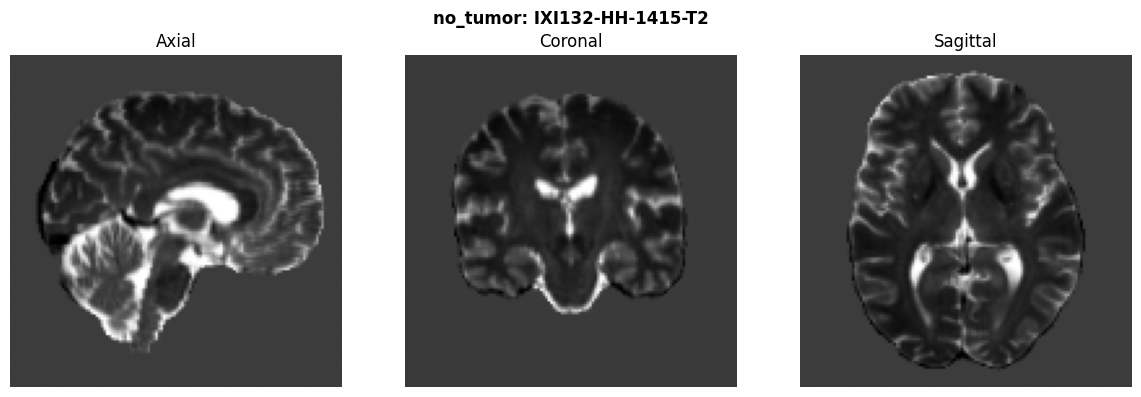

tumor/BraTS-GLI-00113-000-t2w: shape=(128, 128, 128), mean=-0.0000, std=0.4876, nonzero=26.78%


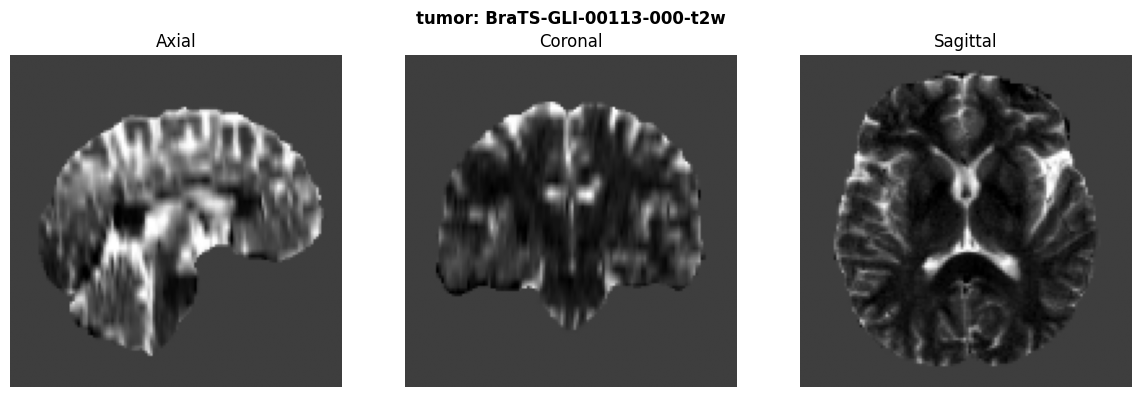

In [ ]:
import matplotlib.pyplot as plt


def validate_preprocessed_cache(records, samples_per_class=1, seed=RANDOM_SEED):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for rec in records:
        by_class[rec.class_name].append(rec)

    for class_name in CLASS_TO_INDEX:
        class_records = by_class.get(class_name, [])
        if not class_records:
            print(f'No cached samples for {class_name}')
            continue

        picks = rng.sample(class_records, k=min(samples_per_class, len(class_records)))
        for rec in picks:
            vol = np.load(rec.path).astype(np.float32)
            nonzero = float(np.count_nonzero(vol)) / vol.size * 100.0
            print(
                f'{class_name}/{rec.patient_id}: shape={vol.shape}, '
                f'mean={vol.mean():.4f}, std={vol.std():.4f}, nonzero={nonzero:.2f}%'
            )

            d, h, w = vol.shape
            views = [
                ('Axial', vol[d // 2, :, :]),
                ('Coronal', vol[:, h // 2, :]),
                ('Sagittal', vol[:, :, w // 2]),
            ]
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            fig.suptitle(f'{class_name}: {rec.patient_id}', fontsize=12, fontweight='bold')
            for ax, (title, img) in zip(axes, views):
                ax.imshow(np.rot90(img), cmap='gray')
                ax.set_title(title)
                ax.axis('off')
            plt.tight_layout()
            plt.show()


validate_preprocessed_cache(records, samples_per_class=1)


## Step 2: Create Fast DataLoaders (from cache)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class Compose3D:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, x):
        for transform in self.transforms:
            x = transform(x)
        return x

class RandomFlip3D:
    """Left-right flip only; avoid superior/inferior or anterior/posterior flips for brain MRI."""
    def __init__(self, p=0.5, axes=(1,)):
        self.p = p
        self.axes = axes

    def __call__(self, x):
        for axis in self.axes:
            if random.random() < self.p:
                x = torch.flip(x, dims=(axis,))
        return x

class RandomIntensityScale3D:
    def __init__(self, scale_range=(0.90, 1.10), p=0.5):
        self.scale_range = scale_range
        self.p = p

    def __call__(self, x):
        if random.random() >= self.p:
            return x
        mask = x != 0
        scale = random.uniform(*self.scale_range)
        return torch.where(mask, x * scale, x)

class RandomGaussianNoise3D:
    def __init__(self, std_range=(0.0, 0.03), p=0.3):
        self.std_range = std_range
        self.p = p

    def __call__(self, x):
        if random.random() >= self.p:
            return x
        mask = x != 0
        noise = torch.randn_like(x) * random.uniform(*self.std_range)
        return torch.where(mask, x + noise, x)


def build_augmentations(augment=False):
    if not augment:
        return None
    return Compose3D([
        RandomFlip3D(p=0.5, axes=(1,)),
        RandomIntensityScale3D(scale_range=(0.95, 1.05), p=0.3),
        RandomGaussianNoise3D(std_range=(0.0, 0.01), p=0.2),
    ])

class CachedVolumeDataset(Dataset):
    """Loads class-structured 128x128x128 cached volumes and adds the channel dimension."""
    def __init__(self, records, cache_dir=None, augment=False):
        self.records = list(records)
        self.cache_dir = cache_dir
        self.transforms = build_augmentations(augment)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        vol = np.load(rec.path).astype(np.float32)
        if vol.shape != TARGET_SHAPE:
            raise ValueError(f'Expected {TARGET_SHAPE}, got {vol.shape} for {rec.path}')
        tensor = torch.from_numpy(vol).float().unsqueeze(0)  # (C, D, H, W)
        if self.transforms:
            tensor = self.transforms(tensor)
        return tensor, torch.tensor(rec.label_index, dtype=torch.long)

kw = {
    'num_workers': NUM_WORKERS,
    'pin_memory': torch.cuda.is_available(),
    'persistent_workers': False,
}

if NUM_WORKERS > 0:
    kw['prefetch_factor'] = 1
train_loader = DataLoader(CachedVolumeDataset(train_records, CACHE_DIR, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True, **kw)
val_loader   = DataLoader(CachedVolumeDataset(val_records, CACHE_DIR, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(CachedVolumeDataset(test_records, CACHE_DIR, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, **kw)

sample_x, sample_y = next(iter(train_loader))
print('Batch shape:', tuple(sample_x.shape), '| Labels:', sample_y.tolist())
print('Fast cached dataloaders ready!')


Batch shape: (8, 1, 128, 128, 128) | Labels: [0, 0, 1, 1, 1, 0, 0, 1]
Fast cached dataloaders ready!


## Step 3: Train ResNet-50

In [ ]:
import math
import os
import time

import numpy as np
import torch
import torch.nn as nn
from monai.networks.nets import ResNet, ResNetBottleneck
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from tqdm.auto import tqdm


def build_3d_resnet50(num_classes, in_channels=1, base_channels=32):
    """MONAI 3D ResNet-50 configured without using the resnet50 wrapper that conflicts across MONAI versions."""
    return ResNet(
        block=ResNetBottleneck,
        layers=[3, 4, 6, 3],
        block_inplanes=[base_channels, base_channels * 2, base_channels * 4, base_channels * 8],
        spatial_dims=3,
        n_input_channels=in_channels,
        num_classes=num_classes,
        conv1_t_size=7,
        conv1_t_stride=2,
        no_max_pool=False,
        shortcut_type='B',
        feed_forward=True,
    )


@torch.inference_mode()
def evaluate_classifier(model, loader, device='cuda', criterion=None):
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []
    losses = []

    for x, y in loader:
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True)
        logits = model(x)
        if criterion is not None:
            losses.append(float(criterion(logits, y).item()))
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_targets.extend(y.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    metrics = {
        'targets': np.array(all_targets),
        'predictions': np.array(all_preds),
        'probabilities': np.array(all_probs),
        'accuracy': accuracy_score(all_targets, all_preds),
        'macro_f1': f1_score(all_targets, all_preds, average='macro', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(all_targets, all_preds),
    }
    if losses:
        metrics['loss'] = float(np.mean(losses))
    return metrics


def train_3d_resnet50(
    train_loader,
    val_loader,
    train_records,
    num_classes,
    epochs=60,
    lr=1e-5,
    weight_decay=1e-4,
    label_smoothing=0.05,
    warmup_epochs=5,
    early_stopping_patience=12,
    max_grad_norm=1.0,
    base_channels=32,
    device='cuda',
    output_dir='.',
):
    os.makedirs(output_dir, exist_ok=True)
    model = build_3d_resnet50(
        num_classes=num_classes,
        in_channels=1,
        base_channels=base_channels,
    ).to(device)

    labels = [r.label_index for r in train_records]
    counts_arr = np.bincount(labels, minlength=num_classes).astype(np.float32)
    counts = counts_arr.tolist()

    # Manual class weights:
    # class 0 = no_tumor
    # class 1 = tumor
    class_weights_np = np.array([1.65, 0.75], dtype=np.float32)

    if num_classes != len(class_weights_np):
        raise ValueError(
            f'Manual class_weights_np has {len(class_weights_np)} weights, '
            f'but num_classes={num_classes}.'
        )

    class_weights = torch.tensor(
        class_weights_np,
        dtype=torch.float32,
        device=device,
    )
    print('Train class counts:', counts)
    print('Class weights:', [round(float(w), 4) for w in class_weights.detach().cpu()])
    print('Tumor2x run: using class-weighted CrossEntropyLoss.')

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    def lr_lambda(epoch_idx):
        if warmup_epochs > 0 and epoch_idx < warmup_epochs:
            return float(epoch_idx + 1) / float(max(1, warmup_epochs))
        progress = float(epoch_idx - warmup_epochs) / float(max(1, epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, max(0.0, progress))))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    use_amp = device.startswith('cuda') and torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_macro_f1': [],
        'val_balanced_acc': [],
        'lr': [],
    }

    best_score = -1.0
    best_epoch = -1
    patience = 0
    ckpt_path = os.path.join(output_dir, 'best_resnet50_3d.pt')

    for epoch in range(epochs):
        start = time.time()
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False)
        for x, y in pbar:
            x = x.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            if max_grad_norm is not None and max_grad_norm > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            preds = logits.detach().argmax(dim=1)
            batch_size = y.size(0)
            running_loss += float(loss.item()) * batch_size
            running_correct += int((preds == y).sum().item())
            running_total += batch_size
            pbar.set_postfix(
                loss=running_loss / max(1, running_total),
                acc=running_correct / max(1, running_total),
            )

        scheduler.step()

        train_loss = running_loss / max(1, running_total)
        train_acc = running_correct / max(1, running_total)
        val_m = evaluate_classifier(model, val_loader, device=device, criterion=criterion)
        val_loss = val_m.get('loss', float('nan'))
        val_acc = val_m['accuracy']
        val_f1 = val_m['macro_f1']
        val_ba = val_m['balanced_accuracy']
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_f1)
        history['val_balanced_acc'].append(val_ba)
        history['lr'].append(current_lr)

        score = val_f1
        improved = score > best_score + 1e-6
        if improved:
            best_score = score
            best_epoch = epoch + 1
            patience = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience += 1

        elapsed = time.time() - start
        print(
            f'Epoch {epoch + 1:03d}/{epochs} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
            f'val_f1={val_f1:.4f} val_ba={val_ba:.4f} | '
            f'lr={current_lr:.2e} | {elapsed:.1f}s'
        )

        if patience >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}, best val macro F1: {best_score:.4f}')
            break

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Training on', DEVICE)

model, history = train_3d_resnet50(
    train_loader=train_loader,
    val_loader=val_loader,
    train_records=train_records,
    num_classes=len(CLASS_TO_INDEX),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    label_smoothing=LABEL_SMOOTHING,
    warmup_epochs=WARMUP_EPOCHS,
    early_stopping_patience=EARLY_STOPPING,
    max_grad_norm=MAX_GRAD_NORM,
    base_channels=BASE_CHANNELS,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Training on cuda
Train class counts: [404.0, 808.0]
Class weights: [1.65, 0.75]
Tumor2x run: using class-weighted CrossEntropyLoss.


Epoch 1/60:   0%|          | 0/152 [00:00<?, ?it/s]

Epoch 001/60 | train_loss=0.8266 train_acc=0.6667 | val_loss=0.6987 val_acc=0.6858 val_f1=0.5077 val_ba=0.5460 | lr=4.00e-06 | 778.2s


Epoch 2/60:   0%|          | 0/152 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a068fc05bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
          ^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a068fc05bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 042/60 | train_loss=0.2685 train_acc=0.9843 | val_loss=0.3061 val_acc=0.9540 val_f1=0.9486 val_ba=0.9511 | lr=2.42e-06 | 25.6s


Epoch 43/60:   0%|          | 0/152 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a068fc05bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
  ^         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a068fc05bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 043/60 | train_loss=0.2680 train_acc=0.9917 | val_loss=0.3246 val_acc=0.9464 val_f1=0.9393 val_ba=0.9368 | lr=2.18e-06 | 25.9s
Early stopping at epoch 43. Best epoch: 31, best val macro F1: 0.9566


## Step 4: Evaluate

Val  -> Acc=0.9617  F1=0.9566  BA=0.9540
Test -> Acc=0.9380  F1=0.9302  BA=0.9302

Test Classification Report:
              precision    recall  f1-score   support

    no_tumor     0.9070    0.9070    0.9070        86
       tumor     0.9535    0.9535    0.9535       172

    accuracy                         0.9380       258
   macro avg     0.9302    0.9302    0.9302       258
weighted avg     0.9380    0.9380    0.9380       258



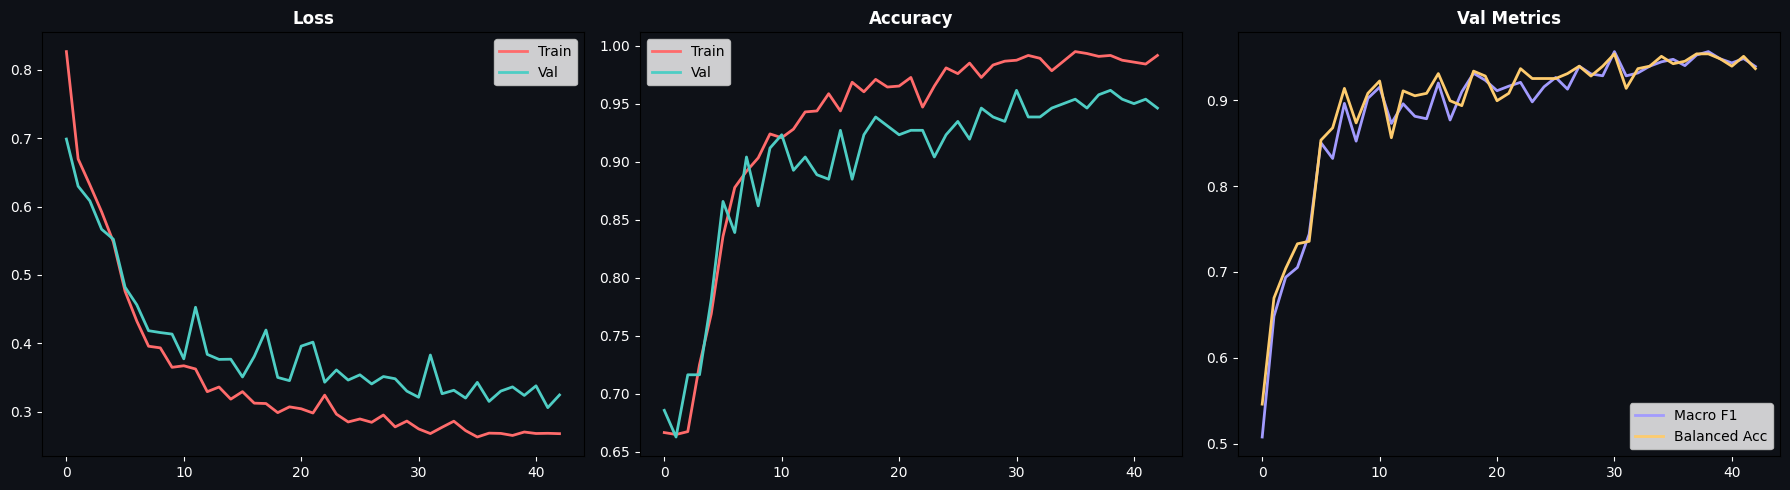

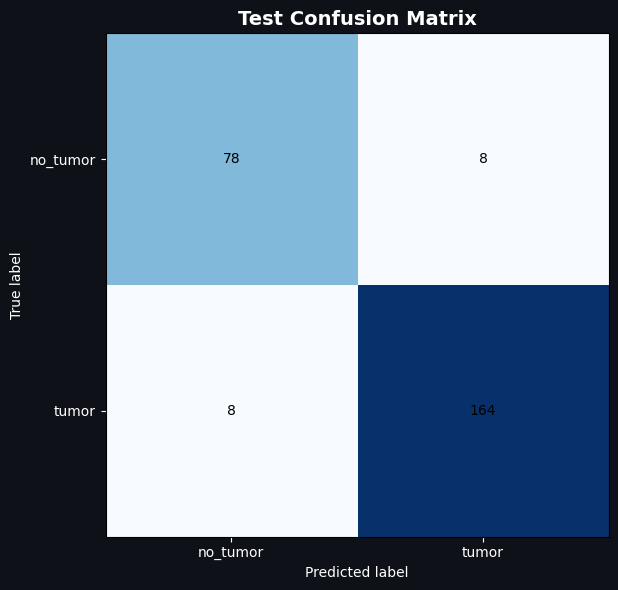

Best checkpoint: /content/drive/MyDrive/gp_data_2026_new_outputs/resnet50_binary_tumor2x_no_tumor_vs_tumor/best_resnet50_3d.pt


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

CKPT = os.path.join(OUTPUT_DIR, 'best_resnet50_3d.pt')
best_model = build_3d_resnet50(num_classes=len(CLASS_TO_INDEX), in_channels=1,
                               base_channels=BASE_CHANNELS).to(DEVICE)
best_model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
best_model.eval()

val_m  = evaluate_classifier(best_model, val_loader,  device=DEVICE)
test_m = evaluate_classifier(best_model, test_loader, device=DEVICE)

print(f"Val  -> Acc={val_m['accuracy']:.4f}  F1={val_m['macro_f1']:.4f}  BA={val_m['balanced_accuracy']:.4f}")
print(f"Test -> Acc={test_m['accuracy']:.4f}  F1={test_m['macro_f1']:.4f}  BA={test_m['balanced_accuracy']:.4f}")

labels = [INDEX_TO_CLASS[i] for i in sorted(INDEX_TO_CLASS)]
print('\nTest Classification Report:')
print(classification_report(test_m['targets'], test_m['predictions'],
                            target_names=labels, digits=4))

# â”€â”€ Training curves â”€â”€
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0e1117')
for ax in axes:
    ax.set_facecolor('#0e1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

axes[0].plot(history['train_loss'], label='Train', color='#ff6b6b', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   color='#4ecdc4', lw=2)
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', color='#ff6b6b', lw=2)
axes[1].plot(history['val_acc'],   label='Val',   color='#4ecdc4', lw=2)
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend()

axes[2].plot(history['val_macro_f1'],     label='Macro F1',     color='#a29bfe', lw=2)
axes[2].plot(history['val_balanced_acc'], label='Balanced Acc', color='#fdcb6e', lw=2)
axes[2].set_title('Val Metrics', fontweight='bold'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, facecolor='#0e1117')
plt.show()

# â”€â”€ Confusion matrix â”€â”€
cm = confusion_matrix(test_m['targets'], test_m['predictions'])
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0e1117')
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_facecolor('#0e1117')
ax.set_title('Test Confusion Matrix', color='white', fontweight='bold', fontsize=14)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
for t in ax.texts:
    t.set_color('black')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, facecolor='#0e1117')
plt.show()

print('Best checkpoint:', CKPT)

## ðŸ”¬ Step 5: Grad-CAM Visualization

Verify the model attends to **brain tissue** (not background) after brain masking.

In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as Fvis
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter

plt.style.use('dark_background')
matplotlib.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'text.color': 'white',
    'font.size': 10,
})


class GradCAMPlusPlus3D:
    def __init__(self, model, target_layer, smooth_sigma=1.0, eps=1e-8):
        self.model = model
        self.target_layer = target_layer
        self.smooth_sigma = smooth_sigma
        self.eps = eps
        self.grads = None
        self.acts = None
        self._hooks = []
        self._register_hooks()

    def _forward_hook(self, module, inputs, output):
        self.acts = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        if grad_output and grad_output[0] is not None:
            self.grads = grad_output[0].detach()

    def _register_hooks(self):
        self._hooks.append(self.target_layer.register_forward_hook(self._forward_hook))
        self._hooks.append(self.target_layer.register_full_backward_hook(self._backward_hook))

    @torch.enable_grad()
    def __call__(self, x, target_class=None):
        self.model.eval()

        x = x.detach().clone().float()
        x.requires_grad_(True)

        logits = self.model(x)
        probs = Fvis.softmax(logits, dim=1)

        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        self.model.zero_grad()

        score = logits[:, target_class].sum()
        score.backward(retain_graph=False)

        if self.acts is None or self.grads is None:
            raise RuntimeError('Grad-CAM++ hooks did not capture activations/gradients.')

        acts = self.acts.float()
        grads = self.grads.float()

        grads_pos = Fvis.relu(grads)
        grads2 = grads ** 2
        grads3 = grads ** 3

        spatial_dims = (2, 3, 4)
        denom = 2.0 * grads2 + (acts * grads3).sum(dim=spatial_dims, keepdim=True)
        denom = torch.where(torch.abs(denom) > self.eps, denom, torch.ones_like(denom) * self.eps)

        alpha = grads2 / denom
        alpha = torch.where(torch.isfinite(alpha), alpha, torch.zeros_like(alpha))

        weights = (alpha * grads_pos).sum(dim=spatial_dims, keepdim=True)
        weights = weights + self.eps * torch.sign(weights)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = Fvis.relu(cam).float()

        cam = Fvis.interpolate(
            cam,
            size=x.shape[2:],
            mode='trilinear',
            align_corners=False,
        )

        cam = cam.squeeze().detach().cpu().numpy().astype(np.float32)

        if self.smooth_sigma is not None and self.smooth_sigma > 0:
            cam = gaussian_filter(cam, sigma=self.smooth_sigma)

        cam = normalize_cam(cam, eps=self.eps)
        cam = np.clip(cam, 0.0, 1.0).astype(np.float32)

        return cam, target_class, probs[0].detach().cpu().numpy()

    def remove(self):
        for hook in list(self._hooks):
            if hook is not None:
                try:
                    hook.remove()
                except RuntimeError:
                    pass
        self._hooks = []


def normalize_cam(cam, eps=1e-8):
    cam = np.asarray(cam, dtype=np.float32)
    cam = np.nan_to_num(cam, nan=0.0, posinf=0.0, neginf=0.0)

    mn = float(np.min(cam))
    mx = float(np.max(cam))
    denom = mx - mn

    if not np.isfinite(denom) or denom <= eps:
        return np.zeros_like(cam, dtype=np.float32)

    cam = (cam - mn) / denom
    return np.clip(cam, 0.0, 1.0).astype(np.float32)


def load_cached_volume(path):
    vol = np.load(path).astype(np.float32)

    if vol.ndim == 4 and vol.shape[0] == 1:
        vol = vol[0]
    elif vol.ndim == 4 and vol.shape[-1] == 1:
        vol = vol[..., 0]

    if vol.ndim != 3:
        raise ValueError(f'Expected cached single-channel 3D volume, got {vol.shape}')

    return vol.astype(np.float32)


def make_brain_mask(vol, min_percentile=5, eps=1e-6):
    vol = np.asarray(vol, dtype=np.float32)
    abs_vol = np.abs(vol)

    candidate = abs_vol[abs_vol > eps]
    if candidate.size < 100:
        return abs_vol > eps

    threshold = np.percentile(candidate, min_percentile)
    mask = abs_vol >= max(float(threshold), eps)

    if np.count_nonzero(mask) < 100:
        mask = abs_vol > eps

    return mask.astype(bool)


def display_slice(slice_2d):
    img = np.asarray(slice_2d, dtype=np.float32)
    mask = make_brain_mask(img, min_percentile=5)

    vals = img[mask] if np.count_nonzero(mask) > 20 else img.reshape(-1)
    lo, hi = np.percentile(vals, [1, 99])

    if hi - lo < 1e-6:
        return np.zeros_like(img, dtype=np.float32)

    out = np.clip(img, lo, hi)
    out = (out - lo) / (hi - lo)
    out[~mask] = 0.0

    return np.clip(out, 0.0, 1.0).astype(np.float32)


def max_cam_slices(cam, brain_mask=None):
    cam = np.asarray(cam, dtype=np.float32)

    if brain_mask is not None:
        cam_for_search = cam * brain_mask.astype(np.float32)
    else:
        cam_for_search = cam

    if not np.isfinite(cam_for_search).all() or float(cam_for_search.max()) <= 0:
        x, y, z = cam.shape
        return x // 2, y // 2, z // 2

    x_idx = int(np.argmax(cam_for_search.sum(axis=(1, 2))))
    y_idx = int(np.argmax(cam_for_search.sum(axis=(0, 2))))
    z_idx = int(np.argmax(cam_for_search.sum(axis=(0, 1))))

    return x_idx, y_idx, z_idx


def rotate_for_display(img):
    return np.rot90(np.asarray(img))


heat_cmap = LinearSegmentedColormap.from_list(
    'brain_heat',
    [
        '#000033', '#0000aa', '#0055ff', '#00ccff',
        '#00ff99', '#aaff00', '#ffcc00', '#ff4400', '#cc0000'
    ],
    N=256,
)


vis_records = []
for ci in range(len(CLASS_TO_INDEX)):
    cls_recs = [r for r in test_records if r.label_index == ci]
    vis_records.extend(cls_recs[:2])


gcampp = GradCAMPlusPlus3D(best_model, best_model.layer4, smooth_sigma=1.0)

try:
    for idx, rec in enumerate(vis_records):
        vol_np = load_cached_volume(rec.path)  # (D, H, W)
        brain_mask_3d = make_brain_mask(vol_np, min_percentile=5)

        inp = (
            torch.from_numpy(vol_np)
            .float()
            .unsqueeze(0)  # batch
            .unsqueeze(0)  # channel
            .to(DEVICE)
        )
        inp.requires_grad_(True)

        cam, pred_cls, probs = gcampp(inp)
        cam = np.clip(cam, 0.0, 1.0).astype(np.float32)

        x_idx, y_idx, z_idx = max_cam_slices(cam, brain_mask=brain_mask_3d)

        true_name = INDEX_TO_CLASS[rec.label_index]
        pred_name = INDEX_TO_CLASS[pred_cls]
        conf = probs[pred_cls] * 100.0
        all_conf = {
            INDEX_TO_CLASS[i]: f'{probs[i] * 100.0:.1f}%'
            for i in range(len(CLASS_TO_INDEX))
        }

        correct = pred_cls == rec.label_index
        mark = 'OK' if correct else 'X'
        border = '#00cc66' if correct else '#ff3333'

        views = [
            ('Sagittal', vol_np[x_idx, :, :], cam[x_idx, :, :], brain_mask_3d[x_idx, :, :], x_idx),
            ('Coronal',  vol_np[:, y_idx, :], cam[:, y_idx, :], brain_mask_3d[:, y_idx, :], y_idx),
            ('Axial',    vol_np[:, :, z_idx], cam[:, :, z_idx], brain_mask_3d[:, :, z_idx], z_idx),
        ]

        fig = plt.figure(figsize=(16, 12), facecolor='#0e1117')
        fig.patch.set_linewidth(4)
        fig.patch.set_edgecolor(border)

        conf_str = ' | '.join(f'{k}: {v}' for k, v in all_conf.items())
        fig.suptitle(
            f'Case {idx + 1}: {rec.patient_id}\n'
            f'True = {true_name} | Pred = {pred_name} ({conf:.1f}%) {mark}\n'
            f'{conf_str}\n'
            f'Grad-CAM++ max slices: sagittal X={x_idx}, coronal Y={y_idx}, axial Z={z_idx}',
            fontsize=12,
            fontweight='bold',
            color=border,
            y=0.985,
            linespacing=1.35,
        )

        gs = gridspec.GridSpec(
            3, 3,
            figure=fig,
            hspace=0.08,
            wspace=0.05,
            top=0.84,
            bottom=0.04,
            left=0.03,
            right=0.95,
        )

        col_titles = ['MRI', 'Grad-CAM++ Overlay', 'Attention Heatmap']

        for row, (view_name, mri_sl, cam_sl, mask_sl, slice_idx) in enumerate(views):
            mri_disp = display_slice(mri_sl)

            cam_sl = np.asarray(cam_sl, dtype=np.float32)
            cam_sl = np.clip(cam_sl, 0.0, 1.0)

            brain_region = mask_sl.astype(np.float32)
            cam_masked = np.clip(cam_sl * brain_region, 0.0, 1.0)

            mri_show = rotate_for_display(mri_disp)
            cam_show = rotate_for_display(cam_masked)

            ax0 = fig.add_subplot(gs[row, 0])
            ax0.imshow(mri_show, cmap='gray', vmin=0, vmax=1)
            ax0.axis('off')
            if row == 0:
                ax0.set_title(col_titles[0], color='#aaaaaa', fontsize=11, pad=6)
            ax0.text(
                0.02,
                0.97,
                f'{view_name} slice {slice_idx}',
                transform=ax0.transAxes,
                color='white',
                fontsize=9,
                va='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#0e1117', alpha=0.7),
            )

            ax1 = fig.add_subplot(gs[row, 1])
            ax1.imshow(mri_show, cmap='gray', vmin=0, vmax=1)
            ax1.imshow(cam_show, cmap='jet', alpha=0.55, vmin=0, vmax=1)
            ax1.axis('off')
            if row == 0:
                ax1.set_title(col_titles[1], color='#aaaaaa', fontsize=11, pad=6)

            ax2 = fig.add_subplot(gs[row, 2])
            ax2.imshow(cam_show, cmap=heat_cmap, vmin=0, vmax=1)
            ax2.axis('off')
            if row == 0:
                ax2.set_title(col_titles[2], color='#aaaaaa', fontsize=11, pad=6)

            if float(cam_show.max()) > 0:
                max_y, max_x = np.unravel_index(np.argmax(cam_show), cam_show.shape)
                ax2.plot(max_x, max_y, 'w+', markersize=9, markeredgewidth=1.3, alpha=0.9)

        sm = plt.cm.ScalarMappable(cmap=heat_cmap, norm=plt.Normalize(vmin=0, vmax=1))
        sm.set_array([])

        cbar_ax = fig.add_axes([0.965, 0.04, 0.012, 0.80])
        cb = fig.colorbar(sm, cax=cbar_ax)
        cb.set_ticks([0, 0.5, 1])
        cb.set_ticklabels(['Low', 'Mid', 'High'])
        cb.ax.tick_params(colors='white')
        cb.outline.set_edgecolor('#444444')

        os.makedirs(OUTPUT_DIR, exist_ok=True)
        save_path = os.path.join(
            OUTPUT_DIR,
            f'gradcampp_maxcam_case_{idx + 1}_{true_name}.png',
        )

        plt.savefig(save_path, dpi=150, facecolor='#0e1117', bbox_inches='tight')
        plt.show()

        print(f'[{idx + 1}] {rec.patient_id} -> saved {save_path}')

finally:
    gcampp.remove()

print(f'\nDone. Single-channel 3D Grad-CAM++ max-CAM visualizations saved to {OUTPUT_DIR}')


Output hidden; open in https://colab.research.google.com to view.